# **Basic Level Task 1**
#**Data Collection and WEB SCRAPING**
**Objectives**
- Identify target website & inspect structure
- Scrape data using BeautifulSoup & requests
- Store data in structured format
- Handle challenges like pagination & dynamic content
 **tools**
 - pyton - beautiful soup - requests - pandas

* -- in the sraping of the data have used the jumia kenya website using the link https://www.jumia.co.ke/robots.txt



In [ ]:
# DATA COLLECTION AND WEB SCRAPING
# ----------------------------------

!pip install beautifulsoup4 requests pandas  # Packages

# Libraries
import requests
from bs4 import BeautifulSoup
import csv
import time
from urllib.parse import urljoin
from google.colab import files
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# User agent (must match Jumia robots.txt requirement)
headers = {
    "User-Agent": "JumiaPriceResearchBot/1.0 (+mailto:your-email@example.com)"
}
# Target does not allow filtering
BASE_URL = "https://www.jumia.co.ke"
CATEGORY_URL = "https://www.jumia.co.ke/smartphones/"
# Fetch HTML page
def get_page_html(url):
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    return response.text
# Parse product cards
def parse_products(html):
    soup = BeautifulSoup(html, "html.parser")
    items = soup.select("article.prd")
    products = []
    for item in items:
        # name
        name_tag = item.select_one("h3.name")
        name = name_tag.get_text(strip=True) if name_tag else None
        price_tag = item.select_one("div.prc")
        price = price_tag.get_text(strip=True) if price_tag else None
        old_price_tag = item.select_one("div.old")
        old_price = old_price_tag.get_text(strip=True) if old_price_tag else None
        link_tag = item.select_one("a.core")
        link = urljoin(BASE_URL, link_tag["href"]) if link_tag else None
        products.append({
            "name": name,
            "price": price,
            "old_price": old_price,
            "link": link
        })
    return products
# Pagination handler
def get_next_page(html):
    soup = BeautifulSoup(html, "html.parser")
    next_btn = soup.select_one("a.pg.next")
    if next_btn:
        return urljoin(BASE_URL, next_btn.get("href"))# pagination type 1
    next_btn2 = soup.find("a", attrs={"aria-label": "Next Page"})
    if next_btn2:
        return urljoin(BASE_URL, next_btn2.get("href"))# pagination type 2
    return None
# scraper
def scrape_jumia():
    url = CATEGORY_URL
    page_num = 1
    all_products = []
    with open("jumia_products.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["name", "price", "old_price", "link"])
        writer.writeheader()
        while url:
            print(f"\n Scraping Page {page_num}: {url}")
            html = get_page_html(url)
            products = parse_products(html)
            if not products:
                print(" No products found on this page. Stopping.")
                break
            writer.writerows(products)
            all_products.extend(products)
            print(f" Extracted {len(products)} products from page {page_num}.") # Save to memory
            time.sleep(3)  # Respect Jumia crawl limits
            url = get_next_page(html)
            page_num += 1
    print("\n\n\n Scraping complete! Saved to 'jumia_products.csv'.")
    return all_products
all_products = scrape_jumia()
df = pd.DataFrame(all_products)
print("=== First 4 Rows ===")
display(df.head(4))
print("=== Last 4 Rows ===")
display(df.tail(4))
print("=== Dataset Info ===")
display(df.info())
print("=== Dataset Description ===")
display(df.describe())
#files.download("jumia_products.csv")



 Scraping Page 1: https://www.jumia.co.ke/smartphones/
 Extracted 80 products from page 1.

 Scraping Page 2: https://www.jumia.co.ke/smartphones/?page=2#catalog-listing
 Extracted 40 products from page 2.

 Scraping Page 3: https://www.jumia.co.ke/smartphones/?page=3#catalog-listing
 Extracted 40 products from page 3.

 Scraping Page 4: https://www.jumia.co.ke/smartphones/?page=4#catalog-listing
 Extracted 40 products from page 4.

 Scraping Page 5: https://www.jumia.co.ke/smartphones/?page=5#catalog-listing
 Extracted 40 products from page 5.

 Scraping Page 6: https://www.jumia.co.ke/smartphones/?page=6#catalog-listing
 Extracted 40 products from page 6.

 Scraping Page 7: https://www.jumia.co.ke/smartphones/?page=7#catalog-listing
 Extracted 40 products from page 7.

 Scraping Page 8: https://www.jumia.co.ke/smartphones/?page=8#catalog-listing
 Extracted 40 products from page 8.

 Scraping Page 9: https://www.jumia.co.ke/smartphones/?page=9#catalog-listing
 Extracted 40 products f

,name,price,old_price,link
0,None,"KSh 7,699",None,https://www.jumia.co.ke/xiaomi-redmi-a3x-6.71-...
1,None,"KSh 9,750",None,https://www.jumia.co.ke/itel-city-100-6.75-6gb...
2,None,"KSh 4,599",None,https://www.jumia.co.ke/villaon-v25-5-22gb-ram...
3,None,"KSh 7,100",None,https://www.jumia.co.ke/villaon-v40s-4g-6.52in...


=== Last 4 Rows ===


,name,price,old_price,link
2036,"Tecno Spark 40, 6.67'' HD+, UP To 256GB ROM+ 8...","KSh 30,999","KSh 40,999",https://www.jumia.co.ke/tecno-spark-40-6.67-hd...
2037,"XIAOMI Redmi Note 13 6.67"" 8GB RAM/256 GB ROM ...","KSh 31,199","KSh 37,000",https://www.jumia.co.ke/xiaomi-redmi-note-13-6...
2038,"Realme C61 6.74'', 128GB ROM + 6GB RAM (Dual ...","KSh 14,799","KSh 29,000",https://www.jumia.co.ke/realme-c61-6.74-128gb-...
2039,Vivo Y21d 6GB RAM + 256GB ROM - 6500mAh 5-Year...,"KSh 23,370","KSh 30,000",https://www.jumia.co.ke/vivo-y21d-6gb-ram-256g...


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       2000 non-null   object
 1   price      2040 non-null   object
 2   old_price  1994 non-null   object
 3   link       2040 non-null   object
dtypes: object(4)
memory usage: 63.9+ KB


None

=== Dataset Description ===


,name,price,old_price,link
count,2000,2040,1994,2040
unique,1702,916,272,2024
top,"Samsung GALAXY A17 5G, 6.7'' HD+, 8GB RAM + 25...","KSh 11,999","KSh 30,999",https://www.jumia.co.ke/agm-note-n1-6.52-displ...
freq,8,23,220,2


## **Basic Level Task 2**
 # **Data Cleaning and Preprocessing**
 **Objectives**

- Handle Missing Data
- Detect and Remove Outliers
- Encode Categorical Variables
- Normalize or Standardize Numerical Data
**tools**
- Python - Pandas - NumPy - Scikit-learn

In [ ]:

# DATA CLEANING AND PREPROCESSING
# --------------------------------
print("=== Dataset Description ===")
display(df.describe())
df = pd.read_csv('jumia_products.csv')
df.drop_duplicates(inplace=True)  # Remove duplicates
df['name'] = df['name'].apply(lambda x: ' '.join(str(x).split()[:4]))# Truncate product name to first four words
def clean_price(x):
    if pd.isna(x):
        return None
    return int(str(x).replace('KSh', '').replace(',', '').strip())# Clean price columns
df['price'] = df['price'].apply(clean_price)
df['old_price'] = df['old_price'].apply(clean_price)
total_rows = df.shape[0]
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / total_rows) * 100 # Handle missing values based on percentage

    if missing_count == 0:
        continue  # No missing values, skip
    if missing_percent < 5:
        df.dropna(subset=[col], inplace=True)
        print(f"Deleted {missing_count} rows from '{col}' (missing <5%)")# delete if missing will be below five percent
    elif 5 <= missing_percent <= 30:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"Imputed missing values in '{col}' with median (missing {missing_percent:.2f}%)")# impute if missing faling in between five and thirty percent
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"Imputed missing values in '{col}' with mode (missing {missing_percent:.2f}%)")# Columns with >30% missing - manual decision
    else:
        print(f"Column '{col}' has high missing percentage ({missing_percent:.2f}%), handle manually")
df['old_price'].fillna(df['price'], inplace=True)# where old doesnt exist filling with current price
df['discount_percent'] = ((df['old_price'] - df['price']) / df['old_price']) * 100
df['discount_percent'] = df['discount_percent'].round(2)
df.dropna(subset=['name', 'link'], inplace=True)
top_discounts = df.sort_values('discount_percent', ascending=False).head(10)
avg_price = df['price'].mean()
summary = df.describe()
df.to_csv('jumia_products_cleaned.csv', index=False)
top_discounts.to_csv('jumia_top_discounts.csv', index=False)#save
print("\n\n\n Completed Cleaned Data")
display(df.style.set_table_styles([
    {'selector': 'thead th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'tbody tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    {'selector': 'tbody tr:hover', 'props': [('background-color', '#ddd')]}
]).set_properties(**{'text-align': 'center'})) #cleaned data printout






=== Dataset Description ===


,name,price,old_price,link
count,2000,2040,1994,2040
unique,1702,916,272,2024
top,"Samsung GALAXY A17 5G, 6.7'' HD+, 8GB RAM + 25...","KSh 11,999","KSh 30,999",https://www.jumia.co.ke/agm-note-n1-6.52-displ...
freq,8,23,220,2


Deleted 46 rows from 'old_price' (missing <5%)



 Completed Cleaned Data


/tmp/ipython-input-38476977.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['old_price'].fillna(df['price'], inplace=True)# where old doesnt exist filling with current price


#**Basic Level Task 3**
# **Exploratory Data Analysis (EDA)**
# **Objectives**
- Compute summary statistics (mean, median, variance, etc.)
- Visualize data using histograms, scatter plots, and box plots
- Identify correlations using a correlation matrix
- Generate a report summarizing EDA insights


,price,old_price,discount_percent
count,1994.000000,1994.000000,1994.000000
mean,18705.428786,29147.277834,35.544584
std,12953.436155,16305.356097,15.766571
min,470.000000,945.000000,0.030000
25%,11482.500000,19500.000000,23.977500
50%,15199.000000,27400.000000,35.290000
75%,22633.750000,35999.000000,47.220000
max,153900.000000,180000.000000,75.600000


,name,link
count,1994,1994
unique,598,1994
top,"Tecno Spark 40, 6.67''",https://www.jumia.co.ke/vivo-y21d-6gb-ram-256g...
freq,68,1


,Rows,Columns
0,1994,5


,Missing Count
name,0
price,0
old_price,0
link,0
discount_percent,0


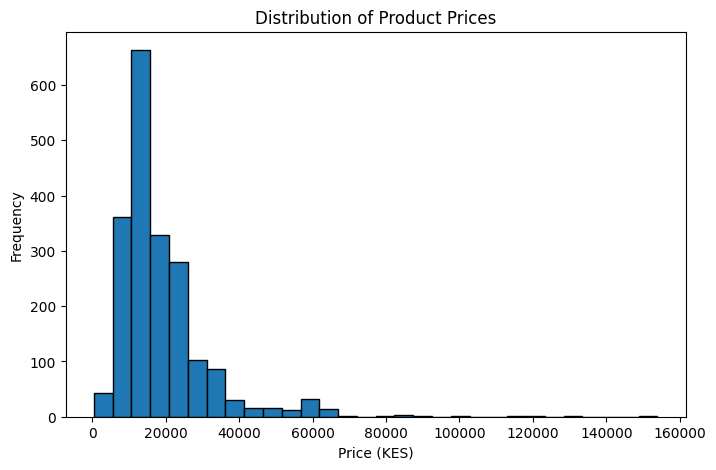

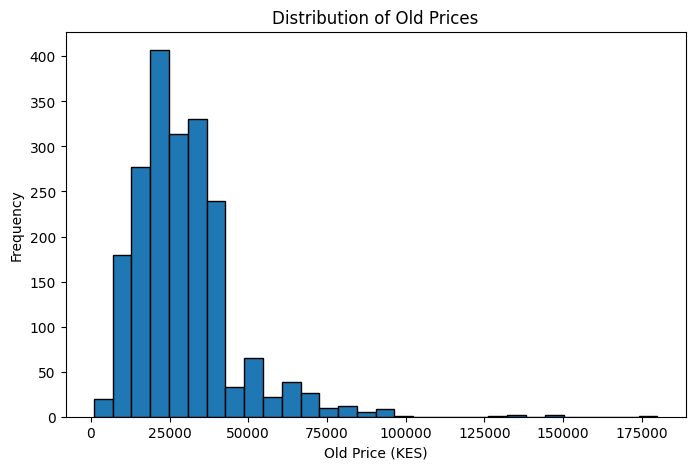

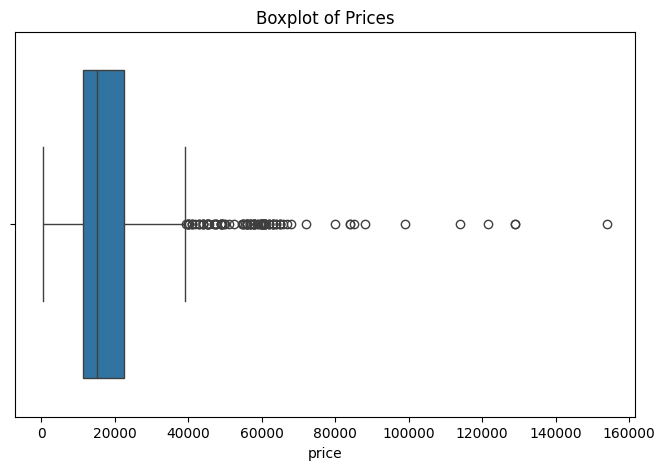

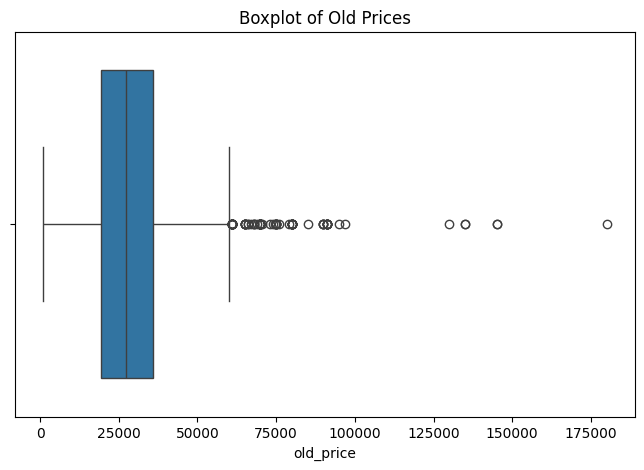

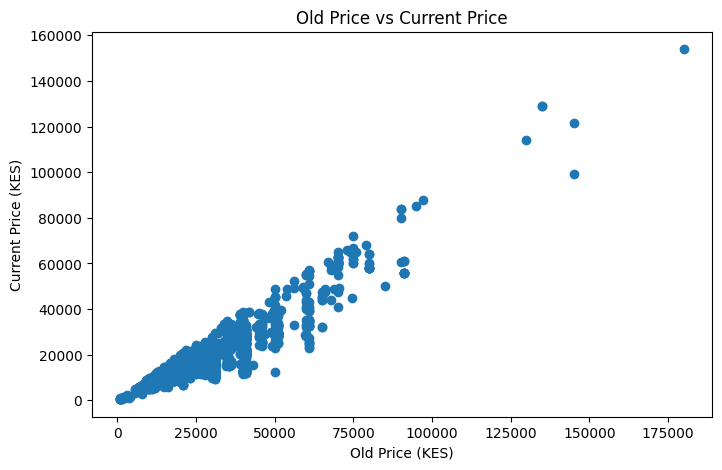

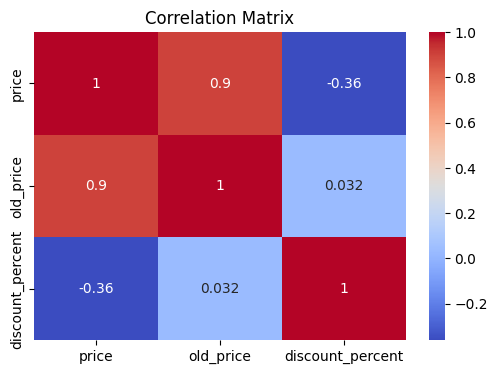


--- Top 20 Products by % Price Variation ---


,name,price,old_price,price_difference,price_difference_percent
264,"Tecno Spark 40, 6.67''",12199,49999.0,37800.0,75.60
743,C29 Pro Smart Watch,1000,3600.0,2600.0,72.22
504,"Realme Note 60 6.74""",11790,40999.0,29209.0,71.24
818,"Realme Note 60 6.74""",11790,40999.0,29209.0,71.24
1046,"Realme Note 60 6.74""",11790,40999.0,29209.0,71.24
440,"XIAOMI Redmi 15C, 6.9'',up",11549,39999.0,28450.0,71.13
1447,"Tecno Spark 40, 6.67''",12290,40999.0,28709.0,70.02
277,"Tecno Spark 40, 6.67''",12015,39999.0,27984.0,69.96
306,"Infinix Hot 60i 4G""6.7-inch,",12049,39999.0,27950.0,69.88
384,"Tecno Spark 40, 6.67''",12398,40999.0,28601.0,69.76



--- Bottom 20 Products by % Price Variation ---


,name,price,old_price,price_difference,price_difference_percent
1675,Infinix NOTE 50 PRO,33999,34999.0,1000.0,2.86
1699,Infinix NOTE 50 PRO,33999,34999.0,1000.0,2.86
878,Itel S25 ULTRA//3D-CURVED SUPER,21399,22000.0,601.0,2.73
1701,Blackview Tab 50 Kids,11699,11999.0,300.0,2.50
494,"Samsung Galaxy A05s, 6.7"",",14599,14950.0,351.0,2.35
269,"Tecno Spark 40, 6.67''",12990,13299.0,309.0,2.32
1380,"Samsung Galaxy A05s, 6.7"",",14687,14999.0,312.0,2.08
997,"Oppo Reno 11F 5G,",48999,49999.0,1000.0,2.00
1879,"Blackview SHARK 8, 6.78"",",20599,20999.0,400.0,1.90
1182,"Realme C65, 6.67"", 256GB",20599,20999.0,400.0,1.90


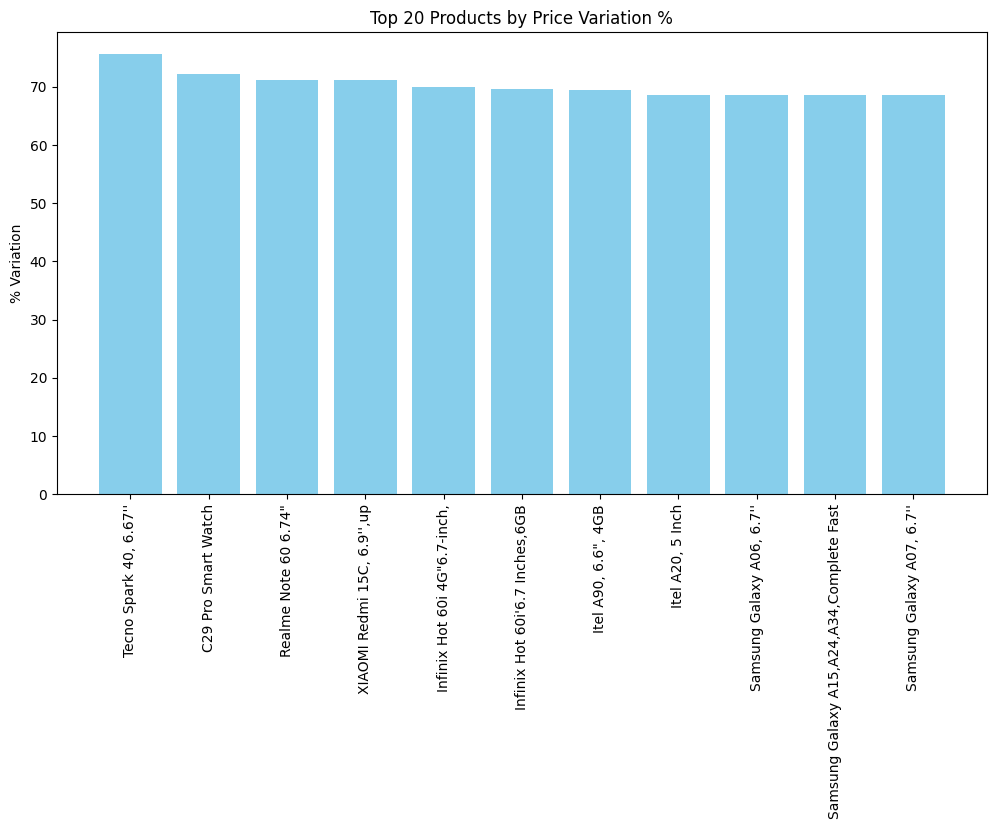

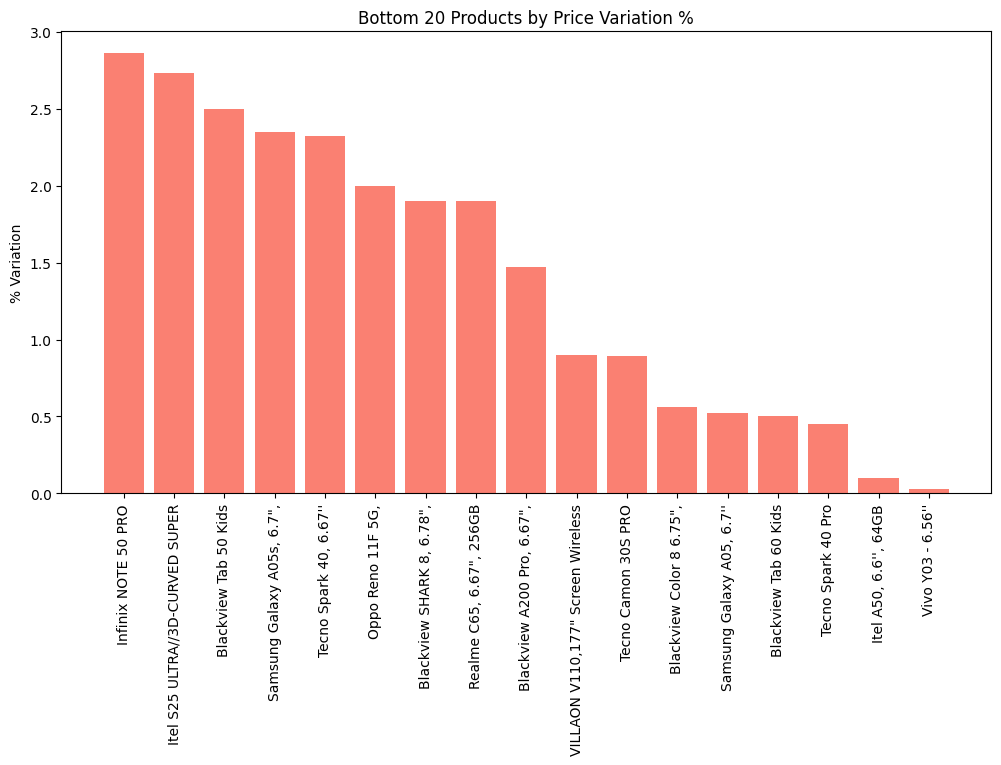

 • Mean Price: 18,705.4288
 • Median Price: 15,199.0000
 • Min Price: 470.0000
 • Max Price: 153,900.0000



 OLD PRICE DISTRIBUTION:
 • Mean Old Price: 29,147.28
 • Average Price Difference: -10,441.8490



 PRICE - OLD PRICE CORRELATION:
0.9013029803360423



 MOST EXPENSIVE PRODUCTS:


,name,price
1002,Apple iPhone 16 Pro,153900
871,Tecno Phantom V Fold,128999
1121,Tecno Phantom V Fold,128999
607,Apple iPhone 15 Pro,121600
475,Samsung Samsung-S25-ULTRA,114000





 CHEAPEST PRODUCTS:


,name,price
255,"Samsung Galaxy A15,A24,A34,Complete Fast",470
248,Samsung USB-C Super Fast,495
522,Samsung Fast Charger 25W,540
1805,Samsung 25 Watts Fast,550
1328,Samsung Fast Charging 25W,580





 UNIQUE PRODUCT COUNT:


598

In [ ]:

display(HTML("<h1><b>===== EXPLORATORY DATA ANALYSIS =====</b></h1>"))
df = pd.read_csv("jumia_products_cleaned.csv")
display(HTML("<h2><b>===== SUMMARY STATISTICS (NUMERICAL DATA) =====</b></h2>"))
display(df.describe())
display(HTML("<h2><b>===== SUMMARY STATISTICS (CATEGORICAL DATA) =====</b></h2>"))
display(df.describe(include='object'))
display(HTML("<h2><b>=====DATASET SHAPE=====</b></h2>"))
shape_table = pd.DataFrame({"Rows": [df.shape[0]], "Columns": [df.shape[1]]})
display(shape_table)
display(HTML("<h2><b>===== CHECK FOR MISSING VALUES =====</b></h2>"))
missing_table = pd.DataFrame(df.isnull().sum(), columns=["Missing Count"])
display(missing_table)
display(HTML("<h2><b>===== HISTOGRAM: PRODUCT PRICES =====</b></h2>"))
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30, edgecolor="black")
plt.title("Distribution of Product Prices")
plt.xlabel("Price (KES)")
plt.ylabel("Frequency")
plt.show()
display(HTML("<h2><b>===== HISTOGRAM: OLD PRICES =====</b></h2>"))
plt.figure(figsize=(8,5))
plt.hist(df["old_price"], bins=30, edgecolor="black")
plt.title("Distribution of Old Prices")
plt.xlabel("Old Price (KES)")
plt.ylabel("Frequency")
plt.show()
display(HTML("<h2><b>===== BOXPLOT: CURRENT PRICE =====</b></h2>"))
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Prices")
plt.show()
display(HTML("<h2><b>===== BOXPLOT: OLD PRICE =====</b></h2>"))
plt.figure(figsize=(8,5))
sns.boxplot(x=df["old_price"])
plt.title("Boxplot of Old Prices")
plt.show()
display(HTML("<h2><b>===== SCATTER PLOT: OLD PRICE VS CURRENT PRICE =====</b></h2>"))
plt.figure(figsize=(8,5))
plt.scatter(df["old_price"], df["price"])
plt.title("Old Price vs Current Price")
plt.xlabel("Old Price (KES)")
plt.ylabel("Current Price (KES)")
plt.show()
display(HTML("<h2><b>===== CORRELATION MATRIX =====</b></h2>"))
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
display(HTML("<h2><b>===== PRICE VARIATION ANALYSIS BASED ON % VARIATION =====</b></h2>"))
df["price_difference"] = df["old_price"] - df["price"]
df["price_difference_percent"] = (df["price_difference"] / df["old_price"]) * 100
df["price_difference_percent"] = df["price_difference_percent"].round(2)
df_sorted = df.sort_values(by="price_difference_percent", ascending=False)
top20 = df_sorted.head(20)
bottom20 = df_sorted.tail(20)
print("\n--- Top 20 Products by % Price Variation ---")
display(top20[["name", "price", "old_price", "price_difference", "price_difference_percent"]])
print("\n--- Bottom 20 Products by % Price Variation ---")
display(bottom20[["name", "price", "old_price", "price_difference", "price_difference_percent"]])
plt.figure(figsize=(12,6))
plt.bar(top20["name"], top20["price_difference_percent"], color='skyblue')
plt.title("Top 20 Products by Price Variation %")
plt.xticks(rotation=90)
plt.ylabel("% Variation")
plt.show()
plt.figure(figsize=(12,6))
plt.bar(bottom20["name"], bottom20["price_difference_percent"], color='salmon')
plt.title("Bottom 20 Products by Price Variation %")
plt.xticks(rotation=90)
plt.ylabel("% Variation")
plt.show()
display(HTML("<h2><b>=====EDA INSIGHTS REPORT=====</b></h2>"))
display(HTML("<h3><b>=====PRICE DISTRIBUTION=====</b></h3>"))
print(f" • Mean Price: {df['price'].mean():,.4f}")
print(f" • Median Price: {df['price'].median():,.4f}")
print(f" • Min Price: {df['price'].min():,.4f}")
print(f" • Max Price: {df['price'].max():,.4f}")
print("\n\n\n OLD PRICE DISTRIBUTION:")
print(f" • Mean Old Price: {df['old_price'].mean():,.2f}")
print(f" • Average Price Difference: {(df['price'] - df['old_price']).mean():,.4f}")
print("\n\n\n PRICE - OLD PRICE CORRELATION:")
print(df["price"].corr(df["old_price"]))
print("\n\n\n MOST EXPENSIVE PRODUCTS:")
display(df.nlargest(5, "price")[["name", "price"]])
print("\n\n\n CHEAPEST PRODUCTS:")
display(df.nsmallest(5, "price")[["name", "price"]])
print("\n\n\n UNIQUE PRODUCT COUNT:")
display(df["name"].nunique())





